In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import session
reload(session)
import h5py
import pickle
from scipy import stats

In [2]:
# set the main data directory (this needs to be changed by each user)
maindir = '/Volumes/ExternalSSD/Credit_assignement'

In [3]:
# get all the sessions to analyze
#mouse = 'M1'
#layers = 'L1' #'L1' 'L23' or 'L5'
#sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
#allsessions = [sess.rstrip('\n') for sess in sessionfile.readlines()]
#sessionfile.close()

#mouse = 'M1'
#layers = 'L23' #'L1' 'L23' or 'L5'
#sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
#allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
#sessionfile.close()

#mouse = 'M2'
#layers = 'L1' #'L1' 'L23' or 'L5'
#sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
#allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
#sessionfile.close()

#mouse = 'M2'
#layers = 'L5' #'L1' 'L23' or 'L5'
#sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
#allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
#sessionfile.close()

mouse = 'M3'
layers = 'L1' #'L1' 'L23' or 'L5'
sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
allsessions = [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()

mouse = 'M3'
layers = 'L23' #'L1' 'L23' or 'L5'
sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()

#mouse = 'M4'
#layers = 'L1' #'L1' 'L23' or 'L5'
#sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
#allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
#sessionfile.close()

#mouse = 'M4'
#layers = 'L5' #'L1' 'L23' or 'L5'
#sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
#allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
#sessionfile.close()


In [4]:
print(allsessions)
nframes = 27 #number of frames to take df/f over

['724422062', '725010342', '726844248', '727683236', '727680211', '725009252', '724421207', '726837871']


In [5]:
# create a dictionary with Session objects prepared for analysis
sdict = {}
gabordict = {}
for sess in allsessions:                       # remove the :1 to get all sessions ready
    print("\nCreating session {}...".format(sess))
    sdict[sess] = session.Session(maindir,sess)    # creates a session object to work with
    sdict[sess].extract_info()  
    gabordict[sess] = session.Stim(sdict[sess],1,'gabors')
    print("finished session {}.".format(sess))
    


Creating session 724422062...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_724422062
Loading running data...
Loading ROI trace info...




finished session 724422062.

Creating session 725010342...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_725010342
Loading running data...
Loading ROI trace info...




finished session 725010342.

Creating session 726844248...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_726844248
Loading running data...
Loading ROI trace info...




finished session 726844248.

Creating session 727683236...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already 

In [31]:
numtotake = 30
pad=(180,135)
sts = []
nts = []
sbas = []
nbas = []
for snum in range(0,4):
    S = allsessions[snum]
    print(S)
    ssegs= sdict[S].gabors.get_segs_by_criteria(gaborframe=3,surp=1,stimPar2=16,remconsec=True)
    sframes = gabordict[S].get_2pframes_by_seg(ssegs[0])
    straces = sdict[S].get_roi_segments(sframes,padding=pad)
    sts.append(straces[:,pad[0]-45:pad[0]+90,0:numtotake])#E responses
    sbas.append(straces[:,0:pad[0],0:numtotake])
    
    nsegs= sdict[S].gabors.get_segs_by_criteria(gaborframe=3,surp=0,stimPar2=16,remconsec=False)
    nframes = gabordict[S].get_2pframes_by_seg(nsegs[0])
    ntraces = sdict[S].get_roi_segments(nframes,padding=pad)
    nts.append(ntraces[:,pad[0]-45:pad[0]+90,0:500])#D responses
    nbas.append(ntraces[:,0:pad[0],0:500])
    
flat_sts  = np.array([item for sublist in sts for item in sublist])
flat_nts = np.array([item for sublist in nts for item in sublist])

flat_nbas = np.array([item for sublist in nbas for item in sublist])
flat_sbas = np.array([item for sublist in sbas for item in sublist])

724422062
725010342
726844248
727683236


<ErrorbarContainer object of 3 artists>

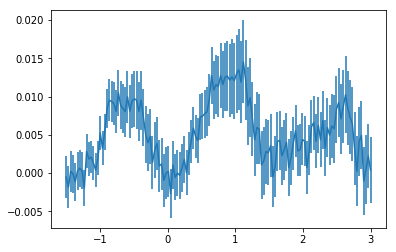

In [32]:
[nrois, other, other2] = np.shape(flat_sts)
roi_dff_sts = np.zeros((nrois,other,other2))
[nrois, other, other4] = np.shape(flat_nts)
roi_dff_nts = np.zeros((nrois,other3,other4))

for roi in range(0,nrois):
    baseline = np.mean(flat_sbas[roi,:,:],axis=0) 
    roi_dff_sts[roi,:,:] = np.divide(flat_sts[roi,:,:] - np.tile(baseline,(other,1)),np.tile(baseline,(other,1)))
    baseline = np.mean(flat_nbas[roi,:,:],axis=0) 
    roi_dff_nts[roi,:,:] = np.divide(flat_nts[roi,:,:] - np.tile(baseline,(other,1)),np.tile(baseline,(other,1)))

    
#plt.plot(np.linspace(-45,other-45,other)/30,np.transpose(np.nanmean(roi_dff_sts,axis=2) - np.nanmean(roi_dff_nts,axis=2)))    
plt.errorbar(np.linspace(-45,other-45,other)/30,np.nanmean(roi_dff_sts,axis=(0,2)) - np.nanmean(roi_dff_nts,axis=(0,2)),np.nanstd(roi_dff_sts,axis=(0,2))/np.sqrt(nrois*numtotake))
#plt.plot(np.linspace(-45,other-45,other)/30,np.transpose(np.nanmean(roi_dff_sts - roi_dff_nts,axis=2)))

In [85]:
numtotake = 30
pad=(60,200)
sts = []
nts = []
sbas = []
nbas = []
for snum in range(4,8):
    S = allsessions[snum]
    print(S)
    ssegs= sdict[S].gabors.get_segs_by_criteria(gaborframe=3,surp=1,stimPar2=16,remconsec=True)
    sframes = gabordict[S].get_2pframes_by_seg(ssegs[0])
    straces = sdict[S].get_roi_segments(sframes,padding=pad)
    sts.append(straces[:,pad[0]-60:pad[0]+180,0:numtotake])#E responses
    sbas.append(straces[:,0:pad[0],0:numtotake])
    
    nsegs= sdict[S].gabors.get_segs_by_criteria(gaborframe=3,surp=0,stimPar2=16,remconsec=False)
    nframes = gabordict[S].get_2pframes_by_seg(nsegs[0])
    ntraces = sdict[S].get_roi_segments(nframes,padding=pad)
    nts.append(ntraces[:,pad[0]-60:pad[0]+180,0:500])#D responses
    nbas.append(ntraces[:,0:pad[0],0:500])
    
flat_sts  = np.array([item for sublist in sts for item in sublist])
flat_nts = np.array([item for sublist in nts for item in sublist])

flat_nbas = np.array([item for sublist in nbas for item in sublist])
flat_sbas = np.array([item for sublist in sbas for item in sublist])

727680211
725009252
724421207
726837871


<ErrorbarContainer object of 3 artists>

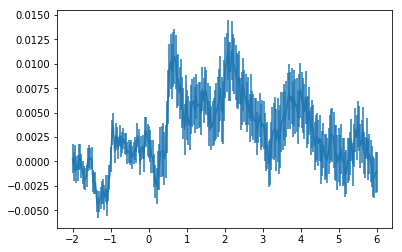

In [87]:
[nrois, other, other2] = np.shape(flat_sts)
roi_dff_sts = np.zeros((nrois,other,other2))
[nrois, other, other4] = np.shape(flat_nts)
roi_dff_nts = np.zeros((nrois,other,other4))

for roi in range(0,nrois):
    baseline = np.mean(flat_sbas[roi,:,:],axis=0) 
    roi_dff_sts[roi,:,:] = np.divide(flat_sts[roi,:,:] - np.tile(baseline,(other,1)),np.tile(baseline,(other,1)))
    baseline = np.mean(flat_nbas[roi,:,:],axis=0) 
    roi_dff_nts[roi,:,:] = np.divide(flat_nts[roi,:,:] - np.tile(baseline,(other,1)),np.tile(baseline,(other,1)))

    
#plt.plot(np.linspace(-45,other-45,other)/30,np.transpose(np.nanmean(roi_dff_sts,axis=2) - np.nanmean(roi_dff_nts,axis=2)))    
plt.errorbar(np.linspace(-60,other-60,other)/30,np.nanmean(roi_dff_sts,axis=(0,2)) - np.nanmean(roi_dff_nts,axis=(0,2)),np.nanstd(roi_dff_sts,axis=(0,2))/np.sqrt(nrois*numtotake))